## visualisation

In [1]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import geopandas as gpd
from shapely.geometry import Point


In [2]:
#load fire data
df_fire_dza = pd.read_csv('../../Datasets/FireDataset/viirs-jpss1_2024_Algeria.csv')
df_fire_tun = pd.read_csv('../../Datasets/FireDataset/viirs-jpss1_2024_Tunisia.csv')

In [3]:
print("Fire Algerian Data Description:")
print(df_fire_dza.describe())
print("\nFire Tunisian Data Description:")
print(df_fire_tun.describe())

Fire Algerian Data Description:
           latitude     longitude    bright_ti4          scan         track  \
count  87446.000000  87446.000000  87446.000000  87446.000000  87446.000000   
mean      31.398370      6.174013    321.170189      0.476433      0.516127   
std        2.642515      2.563073     18.189028      0.101948      0.126665   
min       19.603230     -8.118050    240.170000      0.320000      0.360000   
25%       28.735780      5.585470    305.500000      0.400000      0.400000   
50%       31.403925      6.475440    316.820000      0.450000      0.500000   
75%       32.515890      7.906365    337.420000      0.540000      0.620000   
max       37.022990     10.993650    367.000000      0.800000      0.780000   

           acq_time  version    bright_ti5           frp          type  
count  87446.000000  87446.0  87446.000000  87446.000000  87446.000000  
mean     379.367941      2.0    291.711062      3.454114      1.703863  
std      479.842612      0.0     11.7

In [4]:
#memory usage
print("\nMemory Usage of Algerian Fire Data:")
print(df_fire_dza.info(memory_usage='deep'))
print("\nMemory Usage of Tunisian Fire Data:")
print(df_fire_tun.info(memory_usage='deep'))



Memory Usage of Algerian Fire Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87446 entries, 0 to 87445
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    87446 non-null  float64
 1   longitude   87446 non-null  float64
 2   bright_ti4  87446 non-null  float64
 3   scan        87446 non-null  float64
 4   track       87446 non-null  float64
 5   acq_date    87446 non-null  object 
 6   acq_time    87446 non-null  int64  
 7   satellite   87446 non-null  object 
 8   instrument  87446 non-null  object 
 9   confidence  87446 non-null  object 
 10  version     87446 non-null  int64  
 11  bright_ti5  87446 non-null  float64
 12  frp         87446 non-null  float64
 13  daynight    87446 non-null  object 
 14  type        87446 non-null  int64  
dtypes: float64(7), int64(3), object(5)
memory usage: 32.1 MB
None

Memory Usage of Tunisian Fire Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280

In [5]:
#percentage of missing values in each column
print("\nMissing Values in Algerian Fire Data:")
print(df_fire_dza.isnull().mean() * 100)
print("\nMissing Values in Tunisian Fire Data:")
print(df_fire_tun.isnull().mean() * 100)


Missing Values in Algerian Fire Data:
latitude      0.0
longitude     0.0
bright_ti4    0.0
scan          0.0
track         0.0
acq_date      0.0
acq_time      0.0
satellite     0.0
instrument    0.0
confidence    0.0
version       0.0
bright_ti5    0.0
frp           0.0
daynight      0.0
type          0.0
dtype: float64

Missing Values in Tunisian Fire Data:
latitude      0.0
longitude     0.0
bright_ti4    0.0
scan          0.0
track         0.0
acq_date      0.0
acq_time      0.0
satellite     0.0
instrument    0.0
confidence    0.0
version       0.0
bright_ti5    0.0
frp           0.0
daynight      0.0
type          0.0
dtype: float64


In [6]:
#merge tunisian and algerian fire data
df_fire = pd.concat([df_fire_dza, df_fire_tun], ignore_index=True)
print("\nCombined Fire Data Description:")
print(df_fire.head())


Combined Fire Data Description:
   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0  27.72818    9.87200      295.51  0.76   0.77  2024-01-01         3   
1  28.63288    9.77909      301.80  0.79   0.78  2024-01-01         3   
2  28.64012    9.77953      298.65  0.79   0.78  2024-01-01         3   
3  36.74886    6.25409      338.04  0.46   0.39  2024-01-01       141   
4  35.87978    4.44782      309.49  0.41   0.37  2024-01-01       141   

  satellite instrument confidence  version  bright_ti5   frp daynight  type  
0       N20      VIIRS          n        2      277.66  1.24        N     2  
1       N20      VIIRS          n        2      277.05  1.57        N     2  
2       N20      VIIRS          n        2      277.04  1.34        N     2  
3       N20      VIIRS          n        2      257.28  5.21        N     2  
4       N20      VIIRS          n        2      272.08  1.58        N     2  


## viewing algeria and tunisia separately

### Algeria

In [7]:
df_fire_dza.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,27.72818,9.87200,295.51,0.76,0.77,2024-01-01,3,N20,VIIRS,n,2,277.66,1.24,N,2
1,28.63288,9.77909,301.80,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.05,1.57,N,2
2,28.64012,9.77953,298.65,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.04,1.34,N,2
3,36.74886,6.25409,338.04,0.46,0.39,2024-01-01,141,N20,VIIRS,n,2,257.28,5.21,N,2
4,35.87978,4.44782,309.49,0.41,0.37,2024-01-01,141,N20,VIIRS,n,2,272.08,1.58,N,2


In [8]:
# displaying columns
df_fire_dza.columns

Index(['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_ti5', 'frp', 'daynight', 'type'],
      dtype='object')

In [9]:
# displaying unique values for acq_date, satellite, instrument, confidence, version, daynight and type columns
columns_to_check = ['acq_date', 'satellite', 'instrument', 'confidence', 'version', 'daynight', 'type']

for col in columns_to_check:
    unique_values = df_fire_dza[col].unique()
    if col == "acq_date":
      count = len(unique_values)
      print(f"count of days {count}")
    else:
      print(f"Unique values in '{col}': {unique_values}\n")



count of days 364
Unique values in 'satellite': ['N20']

Unique values in 'instrument': ['VIIRS']

Unique values in 'confidence': ['n' 'h' 'l']

Unique values in 'version': [2]

Unique values in 'daynight': ['N' 'D']

Unique values in 'type': [2 0 3]



In [10]:
# Print data types of all columns
print(df_fire_dza.dtypes)


latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version         int64
bright_ti5    float64
frp           float64
daynight       object
type            int64
dtype: object


#### 0.  Bright_t
Band 4 and Band 5 measure emitted radiation in different thermal wavelengths.

The “brightness temperature” (bright_t) is a measure of how hot the surface appears to the satellite — not necessarily the true physical temperature, but the temperature a blackbody would have to emit the same amount of radiation.

in VIIRS fire detection data:

bright_t4 = Brightness temperature from band M13 (~4 µm, shortwave infrared),

bright_t5 = Brightness temperature from band M15 (~11 µm, thermal infrared),

and the difference bright_t4 - bright_t5 helps identify active fires or hot spots.

#### 🔥 1. frp — Fire Radiative Power

Meaning:

FRP measures the rate of radiative energy being emitted by a fire, in megawatts (MW).

It is proportional to the amount of biomass being burned.

It’s derived from thermal infrared measurements (brightness temperatures) at the fire pixel.

Interpretation:

Higher frp → stronger or larger fire.

It’s used to estimate fire intensity and even CO₂ emissions.


#### 📡 2. scan

Meaning:

The pixel size in the east–west direction (the scan direction), in degrees.

It represents how wide the pixel footprint is across the satellite’s scanning swath.

Why it matters:

Pixels farther from the satellite’s nadir (center of the swath) appear larger and more distorted.

scan helps you correct for geometric distortions or compute actual ground area.

sca = 0.42 → means the pixel covers roughly 0.42° in longitude (east–west).

#### 🛰️ 3. track

Meaning:

The pixel size in the north–south direction (the along-track direction), in degrees.

Similar to scan, but it’s along the satellite’s flight path.

track =0.38 → means the pixel covers ~0.38° in latitude (north–south).


#### Summary 
| Variable    | Meaning                                       | Units          | Notes                           |
| ----------- | --------------------------------------------- | -------------- | ------------------------------- |
| `bright_t4` | Brightness temperature, band 4 (shortwave IR) | Kelvin (K)     | Sensitive to hot fires          |
| `bright_t5` | Brightness temperature, band 5 (thermal IR)   | Kelvin (K)     | Used for background temperature |
| `frp`       | Fire Radiative Power                          | Megawatts (MW) | Measures fire intensity         |
| `scan`      | Pixel size in scan (E–W) direction            | Degrees        | Pixel width across swath        |
| `track`     | Pixel size in track (N–S) direction           | Degrees        | Pixel height along path         |


In [11]:
numerical_columns = ['latitude', 'longitude', 'bright_ti4', 'frp','scan', 'track', 'bright_ti5']
time_columns = ['acq_date', 'acq_time']

### Tunisia

In [12]:
df_fire_tun

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,31.64847,9.16945,315.79,0.53,0.50,2024-01-01,142,N20,VIIRS,n,2,279.09,2.20,N,2
1,31.49290,9.48947,302.32,0.56,0.51,2024-01-01,142,N20,VIIRS,n,2,276.10,1.23,N,0
2,31.49524,9.49053,301.88,0.56,0.51,2024-01-01,142,N20,VIIRS,n,2,276.12,0.77,N,0
3,33.36728,8.54768,302.58,0.45,0.47,2024-01-01,142,N20,VIIRS,n,2,277.15,0.80,N,2
4,31.64812,9.17107,320.80,0.46,0.39,2024-01-02,124,N20,VIIRS,n,2,278.37,2.44,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2799,31.65023,9.17049,308.73,0.50,0.41,2024-12-30,50,N20,VIIRS,n,2,278.50,1.21,N,2
2800,31.64881,9.17031,323.63,0.61,0.53,2024-12-31,31,N20,VIIRS,n,2,279.46,2.57,N,2
2801,31.65072,9.16963,320.75,0.61,0.53,2024-12-31,31,N20,VIIRS,n,2,279.13,3.50,N,2
2802,36.59308,10.31617,296.55,0.63,0.72,2024-12-31,210,N20,VIIRS,n,2,278.94,1.12,N,2


In [13]:
# displaying unique values for acq_date, satellite, instrument, confidence, version, daynight and type columns
columns_to_check = ['acq_date', 'satellite', 'instrument', 'confidence', 'version', 'daynight', 'type']

for col in columns_to_check:
    unique_values = df_fire_tun[col].unique()
    if col == "acq_date":
      count = len(unique_values)
      print(f"count of days {count}")
    else:
      print(f"Unique values in '{col}': {unique_values}\n")


count of days 353
Unique values in 'satellite': ['N20']

Unique values in 'instrument': ['VIIRS']

Unique values in 'confidence': ['n' 'h' 'l']

Unique values in 'version': [2]

Unique values in 'daynight': ['N' 'D']

Unique values in 'type': [2 0 3]



In [14]:
# view dates that exist in df_fire_dz and dont exist in df_fire_tun for "acq_date" object column
# Get unique dates from each dataframe
dz_dates = set(df_fire_dza['acq_date'].unique())
tun_dates = set(df_fire_tun['acq_date'].unique())

# Dates in DZ but not in TUN
dz_not_in_tun = dz_dates - tun_dates

# Optionally, dates in TUN but not in DZ
tun_not_in_dz = tun_dates - dz_dates

print("Dates in DZ not in TUN:", dz_not_in_tun)
print("Dates in TUN not in DZ:", tun_not_in_dz)


Dates in DZ not in TUN: {'2024-09-22', '2024-04-30', '2024-02-18', '2024-04-29', '2024-04-13', '2024-06-10', '2024-05-17', '2024-02-17', '2024-12-05', '2024-04-26', '2024-03-26'}
Dates in TUN not in DZ: set()


### Algeria and tunisia combined

In [15]:
df_fire.head()


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,27.72818,9.87200,295.51,0.76,0.77,2024-01-01,3,N20,VIIRS,n,2,277.66,1.24,N,2
1,28.63288,9.77909,301.80,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.05,1.57,N,2
2,28.64012,9.77953,298.65,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.04,1.34,N,2
3,36.74886,6.25409,338.04,0.46,0.39,2024-01-01,141,N20,VIIRS,n,2,257.28,5.21,N,2
4,35.87978,4.44782,309.49,0.41,0.37,2024-01-01,141,N20,VIIRS,n,2,272.08,1.58,N,2


In [16]:
df_fire[numerical_columns].describe()


,latitude,longitude,bright_ti4,frp,scan,track,bright_ti5
count,90250.000000,90250.000000,90250.000000,90250.000000,90250.000000,90250.000000,90250.000000
mean,31.476760,6.280033,321.091793,3.447776,0.475991,0.515446,291.726092
std,2.666477,2.593748,18.205551,5.222111,0.101596,0.126508,11.700269
min,19.603230,-8.118050,240.170000,0.060000,0.320000,0.360000,244.790000
25%,28.911510,5.642160,305.380000,1.150000,0.400000,0.390000,282.900000
50%,31.409125,6.557880,316.710000,2.060000,0.450000,0.490000,290.790000
75%,32.560313,8.083758,337.400000,3.920000,0.540000,0.620000,298.100000
max,37.323460,11.110350,367.000000,251.890000,0.800000,0.780000,355.420000


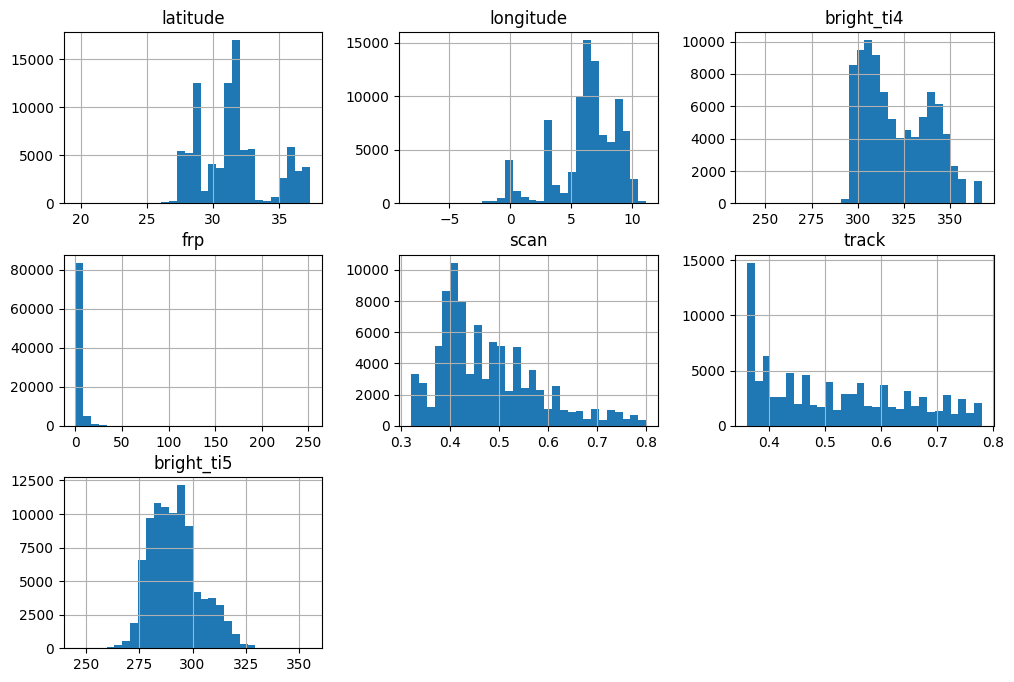

In [17]:
import matplotlib.pyplot as plt
df_fire[numerical_columns].hist(bins=30, figsize=(12,8))
plt.show()


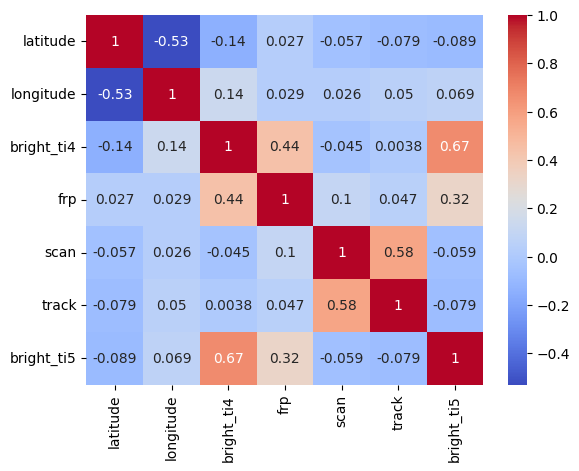

In [18]:
corr = df_fire[numerical_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


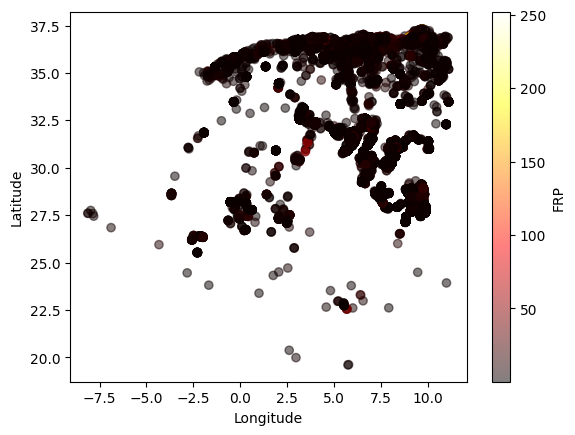

In [19]:
plt.scatter(df_fire['longitude'], df_fire['latitude'], 
            c=df_fire['frp'], cmap='hot', alpha=0.5)
plt.colorbar(label='FRP')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


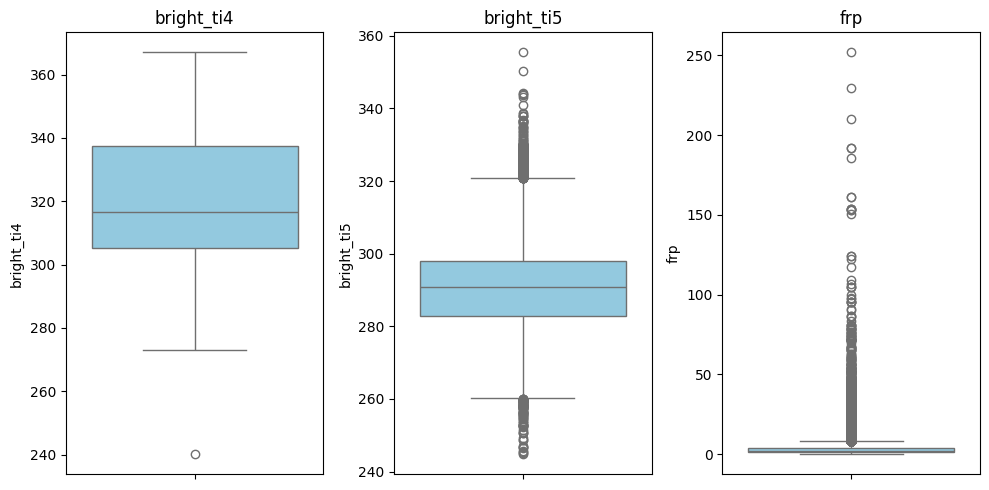

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['bright_ti4', 'bright_ti5', 'frp']

plt.figure(figsize=(10, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, len(cols), i)  # 1 row, n columns
    sns.boxplot(y=df_fire[col], color='skyblue')
    plt.title(col)
    plt.tight_layout()

plt.show()


In [21]:
corr_spearman = df_fire['bright_ti4'].corr(df_fire['bright_ti5'], method='spearman')
print("Spearman correlation between bright_t4 and bright_t5:", corr_spearman)


Spearman correlation between bright_t4 and bright_t5: 0.651405101413597


In [22]:
#  lets analyse time columns
df_fire[['acq_date', 'acq_time']].dtypes

acq_date    object
acq_time     int64
dtype: object

In [23]:
df = df_fire
df['acq_time'] = df['acq_time'].apply(lambda x: f"{int(x):04d}")
import pandas as pd

df['datetime'] = pd.to_datetime(df['acq_date'] + ' ' + df['acq_time'], format='%Y-%m-%d %H%M', errors='coerce')
print("Earliest:", df['datetime'].min())
print("Latest:", df['datetime'].max())
print("Missing values:", df['datetime'].isna().sum())
df['hour'] = df['datetime'].dt.hour
df['hour'].value_counts().sort_index()




Earliest: 2024-01-01 00:03:00
Latest: 2024-12-31 13:32:00
Missing values: 0


hour
0     22827
1     32456
2     13690
3         6
11     4909
12     9898
13     6434
14       30
Name: count, dtype: int64

In [24]:
# displaying type and confidence 
df_fire[['confidence','type']].head()

,confidence,type
0,n,2
1,n,2
2,n,2
3,n,2
4,n,2


In [25]:
# save df_fire
df_fire.to_csv(f"../../Datasets/FireDataset/fire_df.csv", index=False)
